# Введение

## Цель работы
Изучение алгоритмов кластеризации, приобретение навыков оценки качества разбиения данных на кластеры и интерпретации результатов.

## Постановка задачи

1. Загрузить датасет для задачи кластеризации / классификации (например, с платформы Kaggle). Провести дескриптивный анализ данных: определить размерность, типы признаков, наличие пропусков. Оценить распределение переменных (близость к нормальному) с использованием визуализации (гистограммы). Проверить условие применения кластеризации: отсутствие классов, осмысленность кластеризации, отсутствие выбросов.

2. Выполнить стандартизацию / нормализацию числовых признаков. Обосновать выбор метода масштабирования. Построить матрицу диаграмм рассеивания для визуальной оценки структуры данных, предположительного количества кластеров и типа кластерной структуры. Аргументировать выбор методов кластеризации на основе формы, размера и плотности кластеров.

3. Реализовать кластеризацию двумя различными методами на выбор: K-means (K-средних); иерархическая кластеризация; DBSCAN; EM-алгоритм (Gaussian Mixture). Для методов, требующих задания числа кластеров (K-means, иерархическая), подобрать оптимальное значение k с использованием: метода локтя и / или анализа силуэта.

4. Рассчитать метрики качества для обоих методов: внутренние и внешние. Оценить расстояние между кластерами, внутрикластерные расстояния, компактность кластеров, центры кластеров. Опционально, если известно разделение на классы, посчитать: индекс Rand, индекс Жаккара и др. внешние метрики. Привести содержательную интерпретацию полученных значений.

5. Исследовать влияние параметров одного из методов (например, ε и min_samples для DBSCAN или количества кластеров k для K-means) на качество кластеризации.

6. Визуализировать полученные кластеры в пространстве признаков (использовать PCA для снижения размерности при необходимости). Проанализировать центры кластеров (для K-means) и дать содержательную интерпретацию выделенных групп. Сравнить результаты, полученные двумя разными методами.

# Описание датасета

Для работы выбран датасет [Industrial Equipment 🖥️Monitoring 🖲️Dataset](https://www.kaggle.com/datasets/dnkumars/industrial-equipment-monitoring-dataset). 

Этот датасет содержит симулированные данные, имитирующие мониторинг промышленного оборудования в реальном времени, включая турбины, компрессоры и насосы. Каждая строка датасета соответствует уникальному наблюдению и фиксирует ключевые параметры работы оборудования: температуру, давление, уровень вибрации и влажность. Также в набор данных включена информация о типе оборудования, месте его расположения и о том, считается ли оборудование неисправным.

Признаки:

| Название переменной | Тип переменной            | Описание                                                                                                      |
| ---------------     | ------------------------- | ------------------------------------------------------------------------------------------------------------- |
| **temperature**     | Числовая                  | Температура оборудования в момент наблюдения (°C). Характеризует тепловой режим работы.                       |
| **pressure**        | Числовая                  | Давление в системе в момент наблюдения (bar). Отражает рабочие условия и возможные отклонения.                |
| **vibration**       | Числовая                  | Уровень вибрации (нормированные единицы). Повышенные значения могут сигнализировать о механических проблемах. |
| **humidity**        | Числовая                  | Влажность окружающей среды в месте установки оборудования (%). Влияет на условия эксплуатации.                |
| **equipment**       | Категориальная            | Тип промышленного оборудования (например, Turbine, Compressor, Pump).                                         |
| **location**        | Категориальная            | Локация/город, где находится оборудование (например, Atlanta, Chicago и т.д.).                                |
| **faulty**          | Категориальная (бинарная) | Индикатор неисправности: 0 — исправно, 1 — неисправно. Используется для анализа/проверки кластеров.           |







In [29]:
import pandas as pd
import math
import scipy.stats as stats
import matplotlib.pyplot as plt


df = pd.read_csv("Wholesale customers data.csv")
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


## Информация о датасете

In [30]:
print("Размерность (rows, cols):", df.shape)

print("Число объектов (строк):", df.shape[0])
print("Число признаков (столбцов):", df.shape[1])

df.info()

Размерность (rows, cols): (440, 8)
Число объектов (строк): 440
Число признаков (столбцов): 8
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


Как мы видим в датасете отсутвуют пропуски. Признаки temperature, pressure, vibration, humidity являются числовыми, по ним мы и будем проводить кластеризацию. А признакники equipment, location, faulty - категориальные. При этом faulty явялется бинарным и имеет значения 0 или 1; equipment и location уже в виде текста.

## Дескриптивный анализ

,Признак,Среднее,Медиана,Мода,Минимум,Максимум,Стандартное отклонение,Дисперсия,Асимметрия,Эксцесс,Оценка нормальности распредления (тест Колмагорова-Смирнова)
0,Channel,1.32,1.0,1,1,2,0.47,2.200000e-01,0.76,-1.43,p=3.796e-75 → Далеко от нормального
1,Region,2.54,3.0,3,1,3,0.77,6.000000e-01,-1.28,-0.10,p=2.728e-78 → Далеко от нормального
2,Fresh,12000.30,8504.0,3,3,112151,12647.33,1.599549e+08,2.56,11.54,p=8.977e-12 → Далеко от нормального
3,Milk,5796.27,3627.0,577,55,73498,7380.38,5.446997e+07,4.05,24.67,p=6.791e-19 → Далеко от нормального
4,Grocery,7951.28,4755.5,683,3,92780,9503.16,9.031010e+07,3.59,20.91,p=1.986e-16 → Далеко от нормального
5,Frozen,3071.93,1526.0,133,25,60869,4854.67,2.356785e+07,5.91,54.69,p=8.649e-28 → Далеко от нормального
6,Detergents_Paper,2881.49,816.5,3,3,40827,4767.85,2.273244e+07,3.63,19.01,p=1.810e-29 → Далеко от нормального
7,Delicassen,1524.87,965.5,3,3,47943,2820.11,7.952998e+06,11.15,170.69,p=2.306e-34 → Далеко от нормального


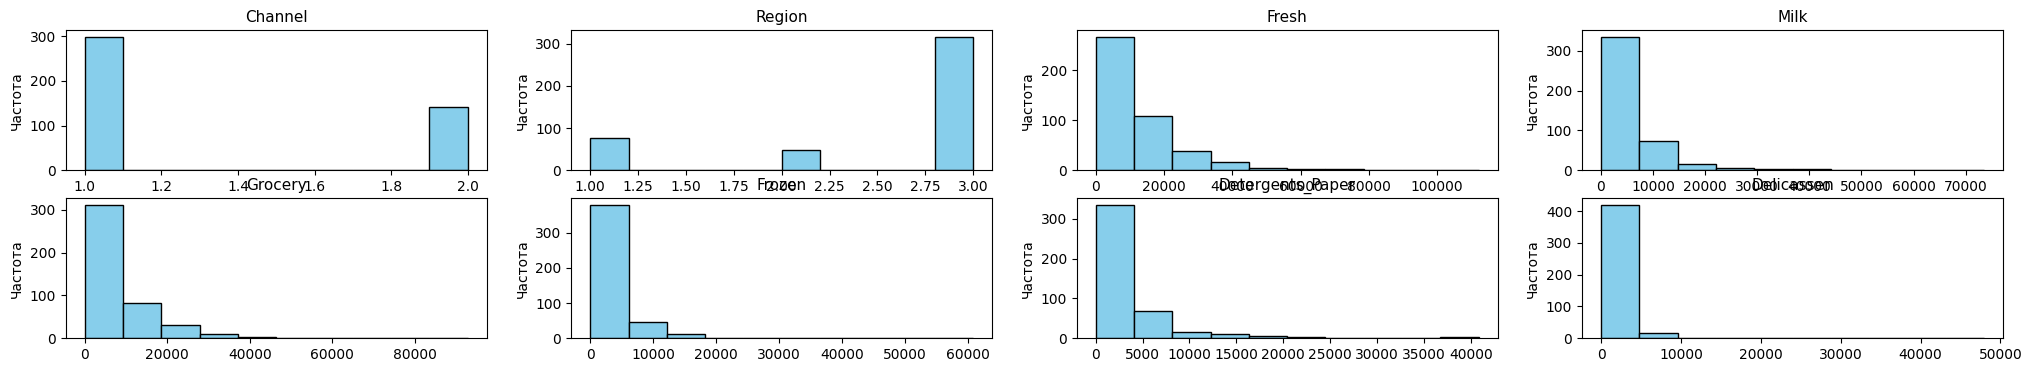

In [35]:
n = df.shape[0]
k = int(math.ceil(1 + math.log2(n)))

def interpret_pvalue(p):
     if p > 0.05:
         return "Нормальное"
     elif p > 0.01:
         return "Близко к нормальному"
     else:
         return "Далеко от нормального"
     
features = df.columns
fig, axes = plt.subplots(2, 4, figsize=(25, 4))
axes = axes.flatten()

stat = {
    "Признак": [], "Среднее": [], "Медиана": [], "Мода": [], "Минимум": [], "Максимум": [],
    "Стандартное отклонение": [], "Дисперсия": [], "Асимметрия": [], "Эксцесс": [],
    "Оценка нормальности распредления (тест Колмагорова-Смирнова)": []
    }

for i, feature in enumerate(features):
    ks_test = stats.kstest(df[feature], 'norm', args=(df[feature].mean(), df[feature].std()))

    stat["Признак"].append(feature)
    stat["Среднее"].append(round(df[feature].mean(), 2))
    stat["Медиана"].append(round(df[feature].median(), 2))
    stat["Мода"].append(round(df[feature].mode()[0], 2))
    stat["Минимум"].append(round(df[feature].min(), 2))
    stat["Максимум"].append(round(df[feature].max(), 2))
    stat["Стандартное отклонение"].append(round(df[feature].std(), 2))
    stat["Дисперсия"].append(round(df[feature].var(), 2))
    stat["Асимметрия"].append(round(df[feature].skew(), 2))
    stat["Эксцесс"].append(round(df[feature].kurtosis(), 2))
    stat["Оценка нормальности распредления (тест Колмагорова-Смирнова)"].append(f"p={ks_test.pvalue:.3e} → {interpret_pvalue(ks_test.pvalue)}")


    k_ = k if feature != "quality" else 6
    axes[i].hist(df[feature], bins=k_, edgecolor='black', color='skyblue')
    axes[i].set_title(feature, fontsize=11)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Частота")

display(pd.DataFrame(stat))

По гистограммам и рассчитанным показателям (асимметрия, эксцесс, тест Колмогорова–Смирнова) видно, что все числовые признаки далеки от нормального распределения.

temperature: среднее 70.92, медиана 70.16 — центр примерно совпадает, но асимметрия 0.94 и высокий эксцесс 5.41 указывают на вытянутый правый хвост и наличие экстремальных значений. Тест Колмогорова–Смирнова даёт p≈2.95e−63, то есть нормальность уверенно отвергается.

pressure: среднее 35.74, медиана 35.23, асимметрия 0.73 и эксцесс 2.36, распределение также с правым хвостом. p≈5.65e−19 → далеко от нормального.

vibration: заметно более «тяжёлое» распределение: асимметрия 1.49 и эксцесс 4.40, что говорит о сильной правосторонней асимметрии и пиковости, вероятно из-за редких режимов повышенной вибрации. p≈2.28e−53 → не нормально.

humidity: почти симметричное (асимметрия −0.02), эксцесс 0.82 — распределение ближе к «приплюснутому», но тест всё равно отвергает нормальность (p≈1.53e−3).

faulty: бинарная переменная (0/1), для неё нормальность в принципе неприменима, и KS-тест закономерно даёт p≈0.

Вывод: признаки имеют ненормальные распределения, что типично для сенсорных данных и не препятствует кластеризации. Однако это важно учитывать при выборе масштабирования (лучше StandardScaler или RobustScaler).





Отсутствие классов:
Для кластеризации используются только признаки-описания объекта. Переменная faulty является целевой/контрольной меткой (0 — норма, 1 — неисправность) и не должна включаться в кластеризацию.
Таким образом, условие “отсутствие заранее заданных классов” соблюдается: кластеры строятся без использования меток.

Осмысленность кластеризации:
Кластеризация здесь имеет практический смысл: по показаниям датчиков можно выделить режимы работы оборудования (нормальные и аномальные), а затем проверить, концентрируются ли неисправности в отдельных кластерах. Это соответствует задаче мониторинга промышленного оборудования.

Отсутствие выбросов / работа с выбросами:
По статистике видно наличие “тяжёлых хвостов”, особенно у temperature и vibration (высокий эксцесс и асимметрия). Это означает, что выбросы или экстремальные режимы вероятны.
Для сенсорных данных такие точки часто отражают реальные аварийные состояния, поэтому их не нужно автоматически удалять. Корректный подход:

проверить выбросы визуально (boxplot);

для кластеризации применить устойчивое масштабирование (например, RobustScaler), чтобы выбросы не “перетягивали” расстояния;

при необходимости можно отдельно отметить экстремальные точки как потенциальные аномалии.

Вывод: данные подходят для кластеризации; при этом из-за ненормальности и возможных выбросов нужно использовать нормализацию/масштабирование и интерпретировать экстремальные значения как возможные аномальные режимы.


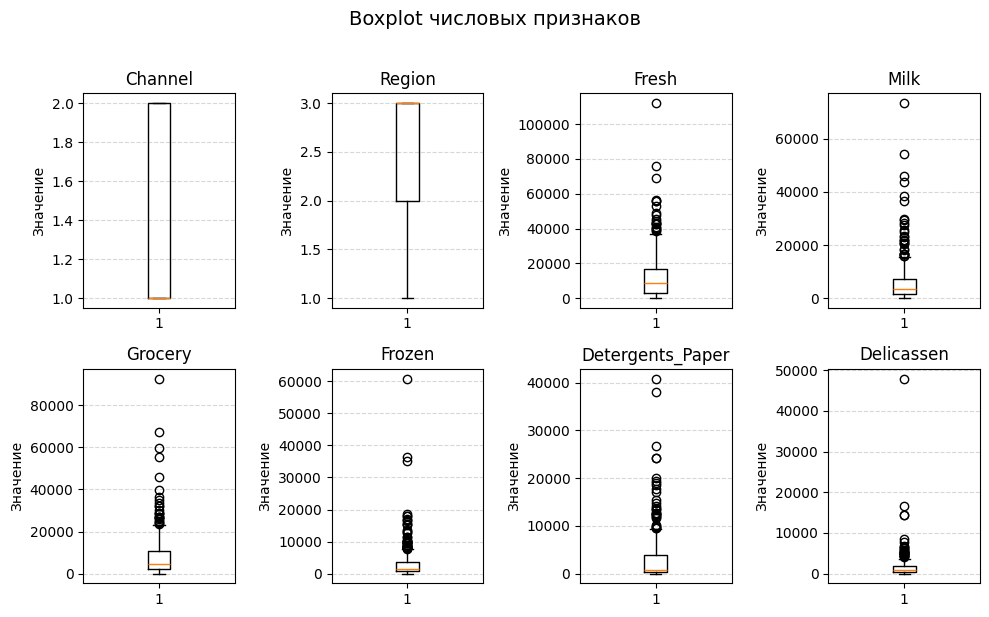

In [39]:
import matplotlib.pyplot as plt

num_cols = df.columns

fig, axes = plt.subplots(2, 4, figsize=(10, 6))
axes = axes.ravel()

for ax, col in zip(axes, num_cols):
    ax.boxplot(df[col].dropna(), vert=True)
    ax.set_title(col)
    ax.set_ylabel("Значение")
    ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.suptitle("Boxplot числовых признаков", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


Судя по твоим boxplot’ам, картина такая:

temperature

Ящик (IQR) узкий вокруг ~65–75, медиана около 70.

Очень много точек выше верхнего уса (примерно >100) и заметно ниже нижнего (примерно <40).

Это означает длинные хвосты и много экстремальных режимов/значений → совпадает с высокой асимметрией и эксцессом в таблице.

pressure

Центр около 30–40, медиана ~35.

Есть выбросы и снизу (очень малые давления), и сверху (до ~80).

Хвосты тоже выраженные, но чуть спокойнее, чем у температуры.

vibration

Основная масса ~1.1–2.0, медиана ~1.5.

Сверху хвост до ~5 — много выбросов.

Есть и отрицательные значения (ниже 0). Для “нормированных единиц” это может быть допустимо (если нормировка относительно нуля), но это точно экстремальные режимы.

humidity

Основная масса ~40–60, медиана ~50.

Выбросы есть, но меньше “катастрофы”, чем в temperature/vibration; хвосты вверх до ~90 и вниз до ~10–20.

По boxplot-графикам выявлены выраженные выбросы в сенсорных признаках, особенно temperature и vibration. Для данных мониторинга оборудования эти экстремальные значения интерпретируются как возможные аномальные режимы работы, поэтому они не удалялись. Для снижения влияния выбросов на расстояния при кластеризации применялось устойчивое масштабирование RobustScaler.

In [42]:
from sklearn.preprocessing import RobustScaler

num_cols = df.columns

# только числовые признаки
X_num = df[num_cols].copy()

# RobustScaler
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_num)

# обратно в DataFrame для удобства
df_scaled = df.copy()
df_scaled[num_cols] = X_scaled

df_scaled.head()


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,1.0,0.0,0.301680,1.065712,0.329952,-0.466572,0.506787,0.263810
1,1.0,0.0,-0.104810,1.092934,0.565993,0.083926,0.675670,0.574008
2,1.0,0.0,-0.155802,0.915816,0.344418,0.312589,0.736512,4.871459
3,0.0,0.0,0.344850,-0.429714,-0.062862,1.734708,-0.084442,0.582507
4,1.0,0.0,1.022092,0.315171,0.287260,0.849573,0.262056,2.988314


Для масштабирования числовых признаков выбран метод RobustScaler, так как по boxplot-графикам выявлены выраженные выбросы в признаках temperature и vibration, а также ненормальные распределения всех сенсорных параметров. RobustScaler использует медиану и межквартильный размах (IQR), поэтому устойчив к экстремальным значениям и не позволяет выбросам доминировать в метрике расстояния, что критично для алгоритмов кластеризации на основе расстояний.

<Figure size 1000x1000 with 0 Axes>

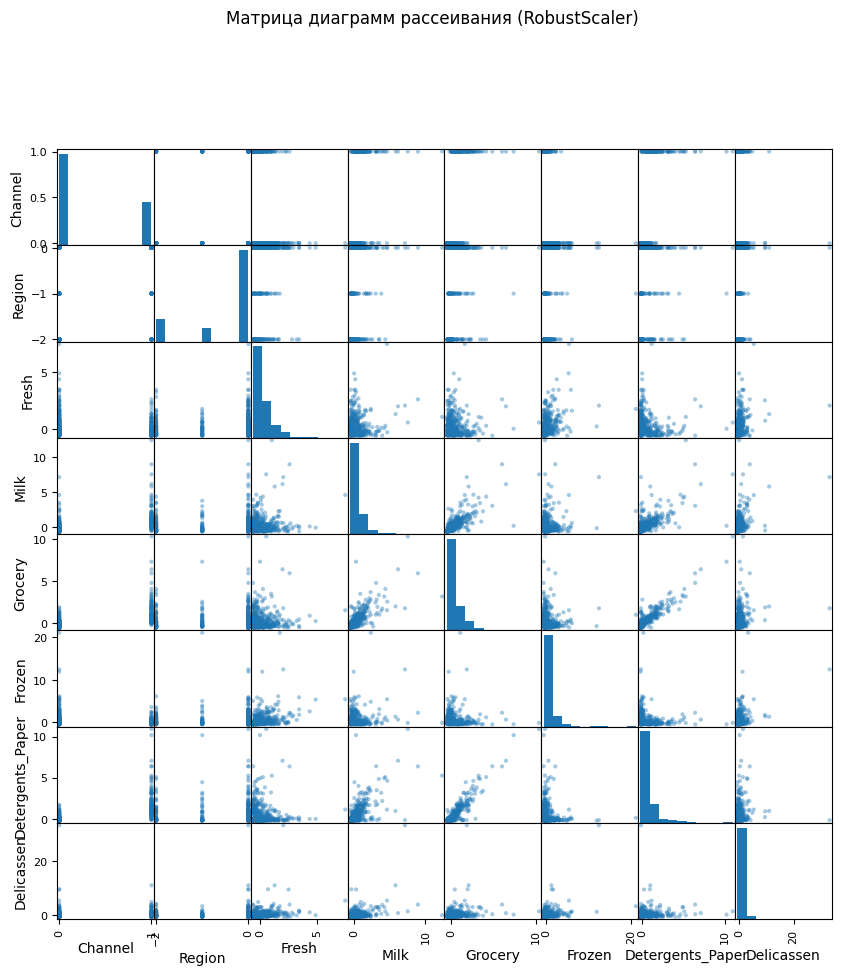

In [43]:
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

# матрица рассеивания на RobustScaler-данных
plt.figure(figsize=(10, 10))
scatter_matrix(
    df_scaled[num_cols],
    figsize=(10, 10),
    diagonal="hist",
    alpha=0.4
)
plt.suptitle("Матрица диаграмм рассеивания (RobustScaler)", y=1.02)
plt.show()


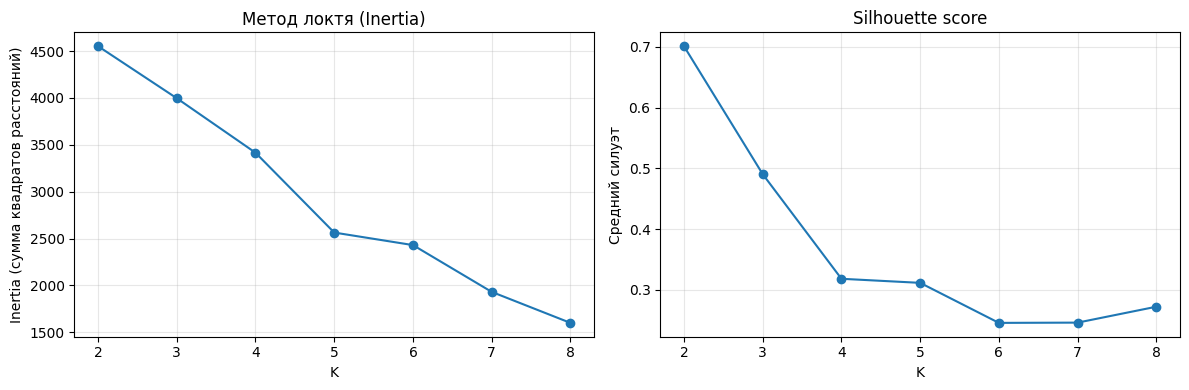

K=2: inertia=4552.48, silhouette=0.701
K=3: inertia=3997.06, silhouette=0.491
K=4: inertia=3415.54, silhouette=0.318
K=5: inertia=2563.65, silhouette=0.312
K=6: inertia=2429.92, silhouette=0.246
K=7: inertia=1930.61, silhouette=0.246
K=8: inertia=1599.86, silhouette=0.272


In [45]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

num_cols = df.columns

X = df_scaled[num_cols].values  # уже RobustScaler!

Ks = range(2, 9)  # обычно смотрят 2..8
inertias = []
silhouettes = []

for k in Ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

# --- графики локтя и силуэта на одной картинке ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(Ks, inertias, marker='o')
axes[0].set_title("Метод локтя (Inertia)")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inertia (сумма квадратов расстояний)")
axes[0].grid(alpha=0.3)

axes[1].plot(Ks, silhouettes, marker='o')
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Средний силуэт")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# табличкой, чтобы проще было выбрать
for k, iner, sil in zip(Ks, inertias, silhouettes):
    print(f"K={k}: inertia={iner:.2f}, silhouette={sil:.3f}")


Размерность (rows, cols): (7195, 26)

Типы признаков и пропуски:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7195 entries, 0 to 7194
Data columns (total 26 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   MFCCs_ 1  7195 non-null   float64
 1   MFCCs_ 2  7195 non-null   float64
 2   MFCCs_ 3  7195 non-null   float64
 3   MFCCs_ 4  7195 non-null   float64
 4   MFCCs_ 5  7195 non-null   float64
 5   MFCCs_ 6  7195 non-null   float64
 6   MFCCs_ 7  7195 non-null   float64
 7   MFCCs_ 8  7195 non-null   float64
 8   MFCCs_ 9  7195 non-null   float64
 9   MFCCs_10  7195 non-null   float64
 10  MFCCs_11  7195 non-null   float64
 11  MFCCs_12  7195 non-null   float64
 12  MFCCs_13  7195 non-null   float64
 13  MFCCs_14  7195 non-null   float64
 14  MFCCs_15  7195 non-null   float64
 15  MFCCs_16  7195 non-null   float64
 16  MFCCs_17  7195 non-null   float64
 17  MFCCs_18  7195 non-null   float64
 18  MFCCs_19  7195 non-null   float64
 19  MFCC

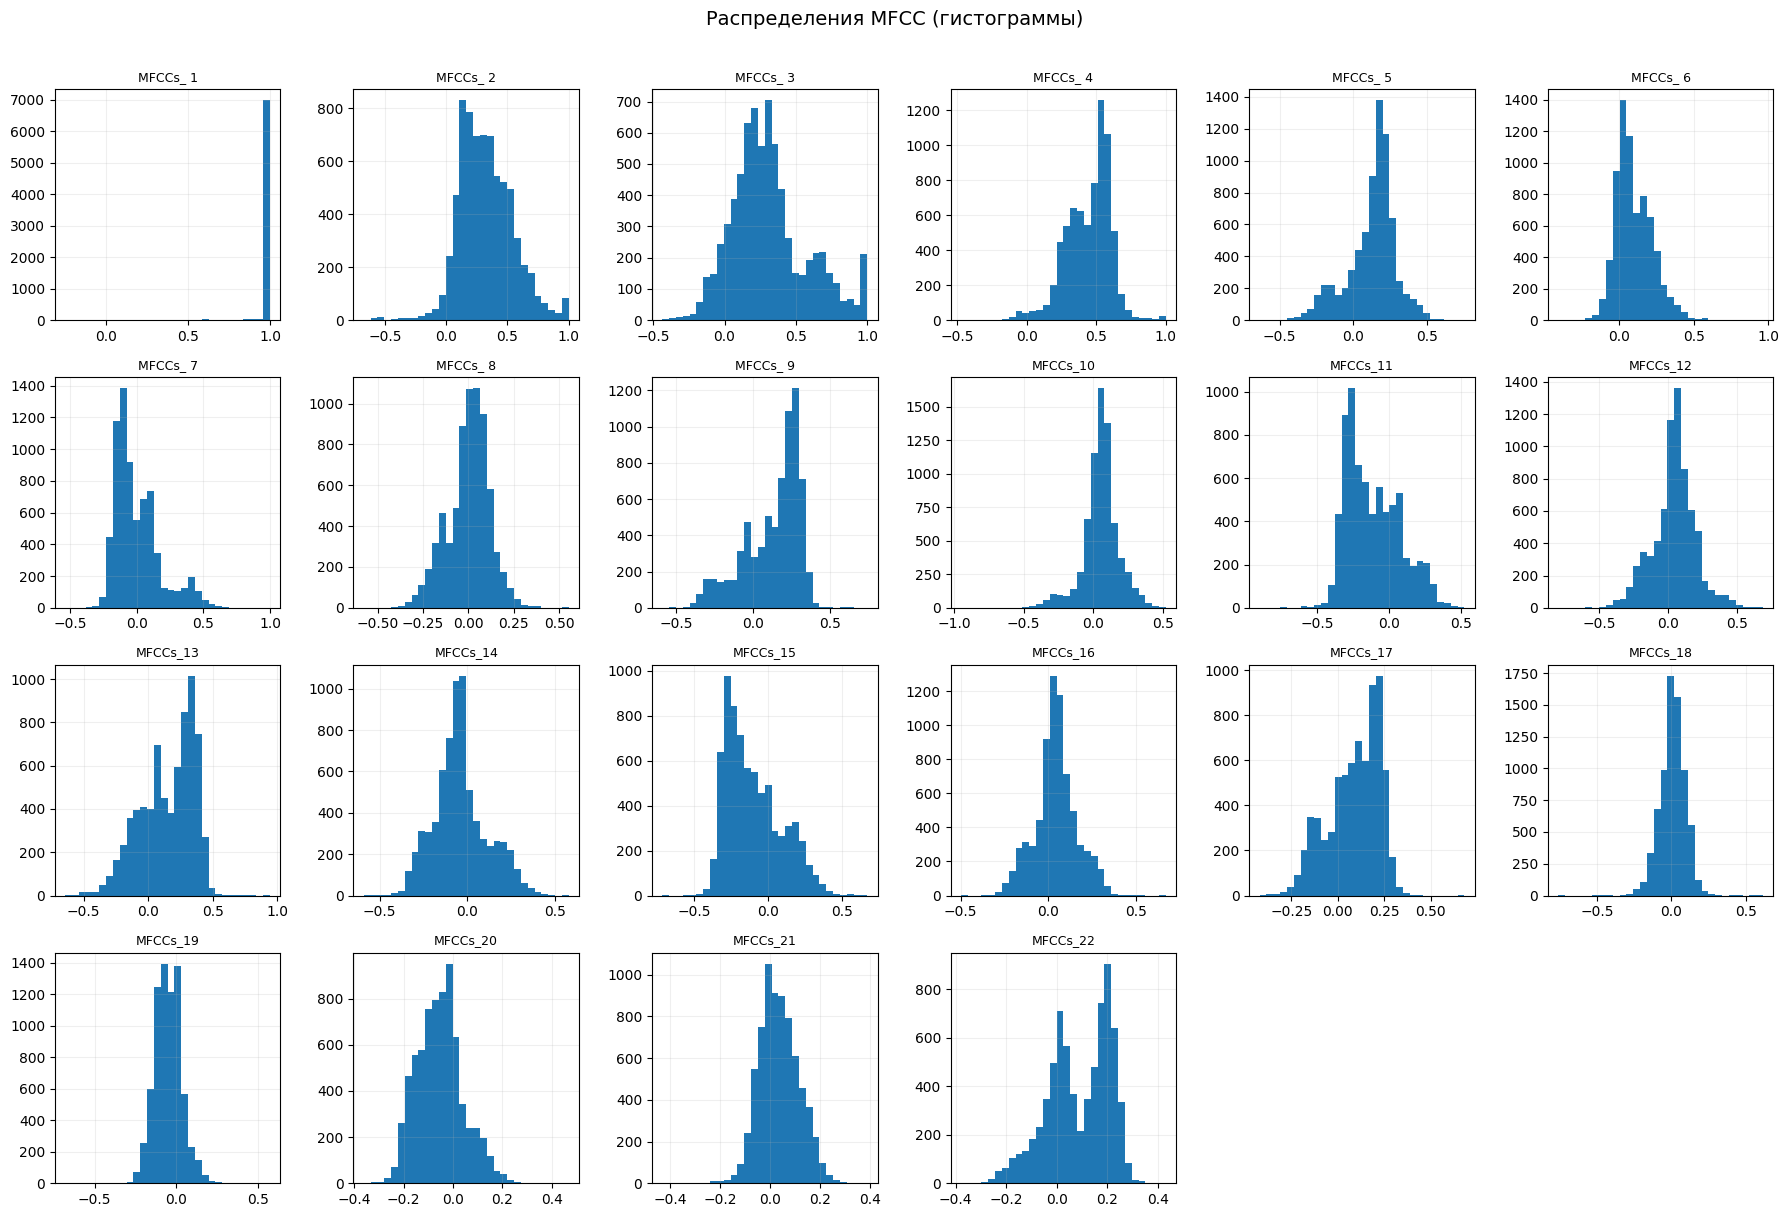

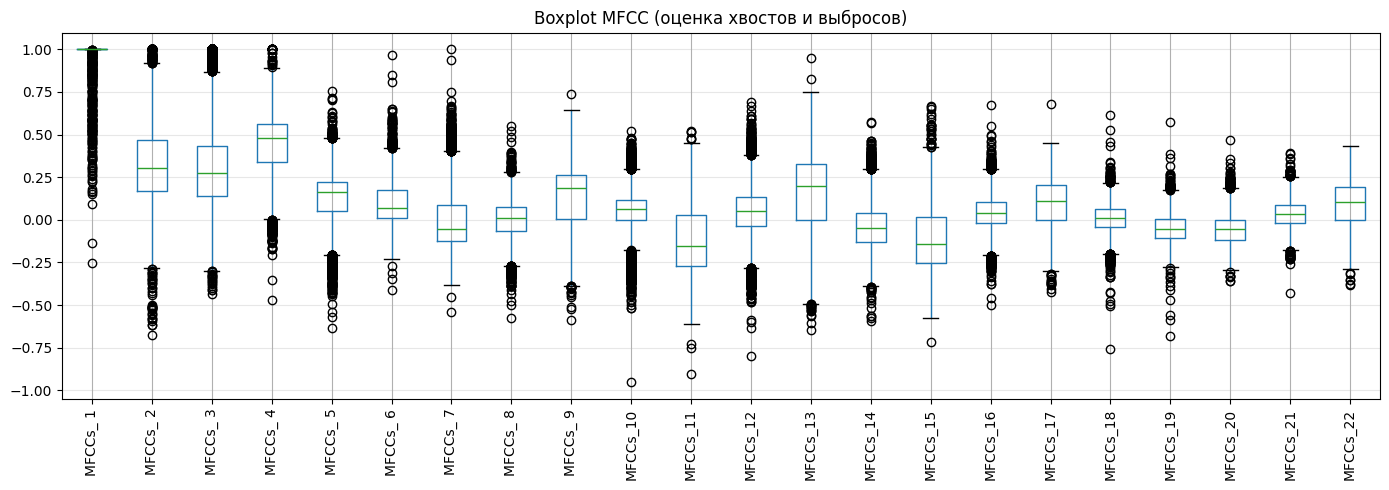

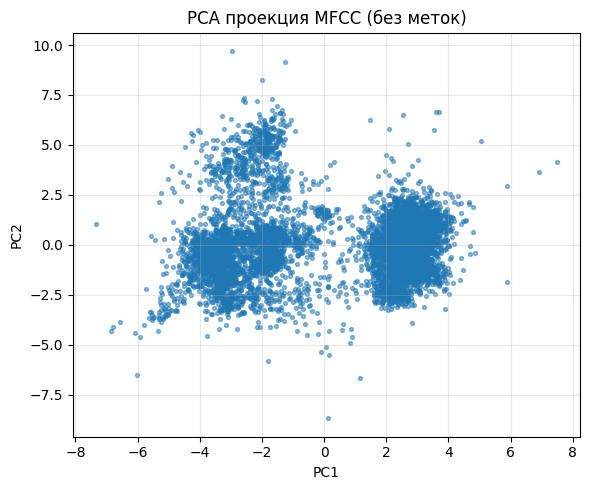

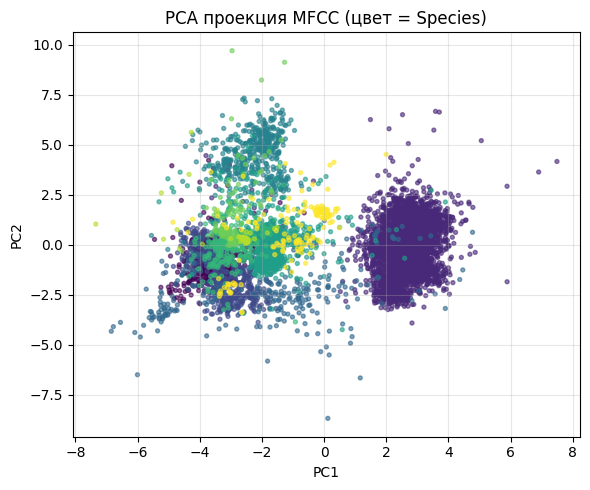

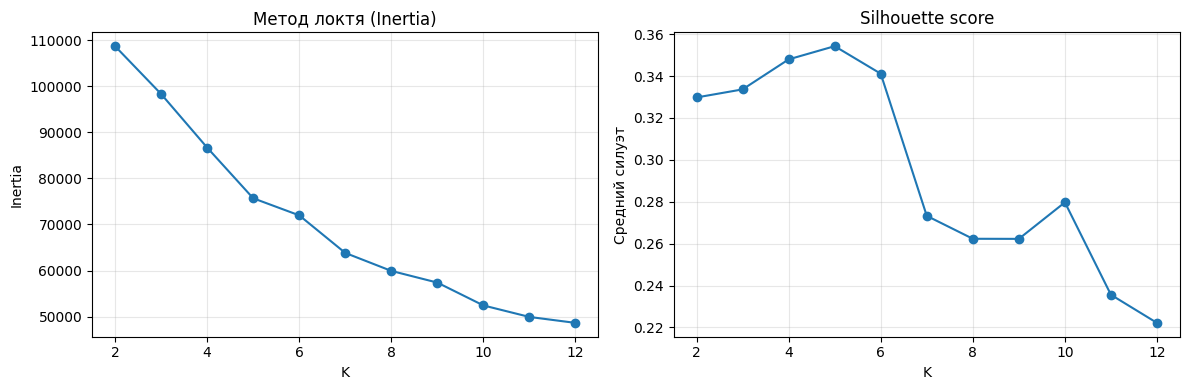


Таблица inertia и silhouette:
K=2: inertia=108667.95, silhouette=0.330
K=3: inertia=98299.48, silhouette=0.334
K=4: inertia=86674.22, silhouette=0.348
K=5: inertia=75684.10, silhouette=0.354
K=6: inertia=71977.75, silhouette=0.341
K=7: inertia=63826.16, silhouette=0.273
K=8: inertia=59928.47, silhouette=0.262
K=9: inertia=57392.00, silhouette=0.262
K=10: inertia=52438.36, silhouette=0.280
K=11: inertia=49942.59, silhouette=0.236
K=12: inertia=48654.18, silhouette=0.222

Авто-подсказка:
Лучший K по silhouette: 5 (silhouette=0.354)
Доля объясненной дисперсии PCA(2): 0.498


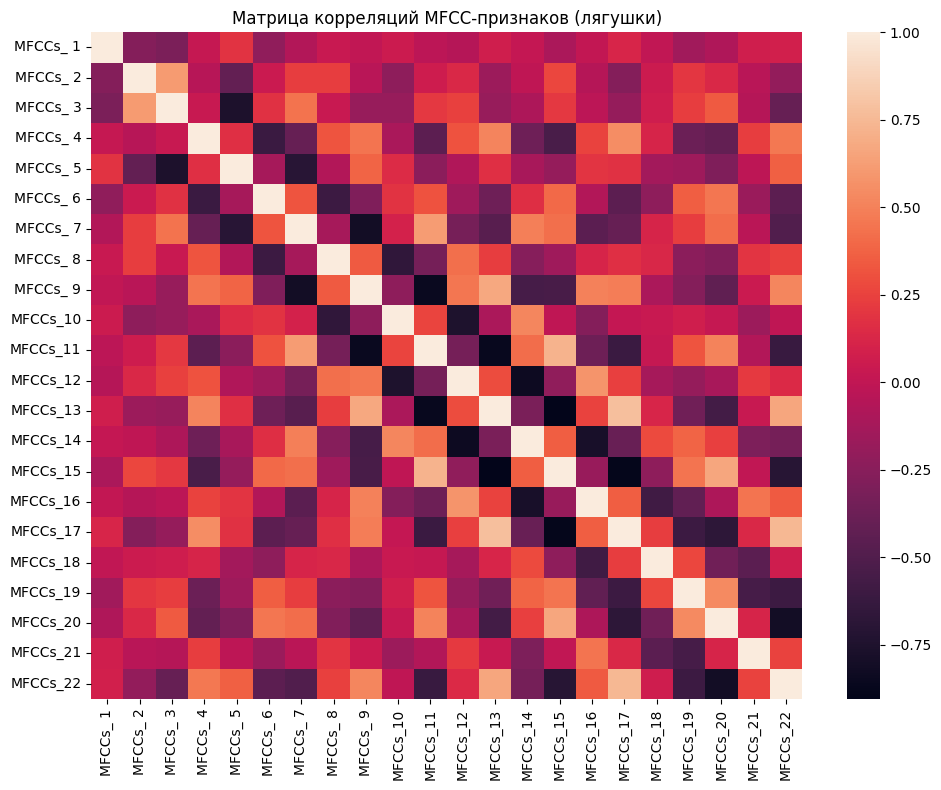

k для 90% дисперсии: 9 (cum_var=0.910)

Матрица компонент PCA (loadings):


,MFCCs_ 1,MFCCs_ 2,MFCCs_ 3,MFCCs_ 4,MFCCs_ 5,MFCCs_ 6,MFCCs_ 7,MFCCs_ 8,MFCCs_ 9,MFCCs_10,...,MFCCs_13,MFCCs_14,MFCCs_15,MFCCs_16,MFCCs_17,MFCCs_18,MFCCs_19,MFCCs_20,MFCCs_21,MFCCs_22
PCA1,0.048,-0.080,-0.118,0.237,0.144,-0.201,-0.259,0.148,0.287,-0.093,...,0.295,-0.226,-0.292,0.194,0.297,-0.004,-0.224,-0.257,0.089,0.297
PCA2,-0.136,0.285,0.341,0.032,-0.247,0.028,0.053,0.224,0.065,-0.393,...,-0.081,-0.323,0.148,0.267,-0.114,-0.196,-0.012,0.186,0.192,-0.138
PCA3,-0.108,0.263,0.288,0.141,-0.330,-0.208,0.198,0.240,-0.044,-0.101,...,0.150,0.145,-0.167,-0.336,0.122,0.486,0.124,-0.189,-0.253,0.017
PCA4,0.214,-0.065,-0.008,0.132,-0.197,-0.281,0.328,0.149,-0.332,0.053,...,-0.109,0.093,0.017,-0.006,0.122,-0.083,-0.451,-0.055,0.487,0.136
PCA5,0.299,-0.057,-0.320,-0.012,0.290,-0.349,-0.163,0.457,0.024,-0.345,...,-0.206,0.059,0.239,-0.159,-0.245,0.131,0.132,-0.018,-0.057,-0.086
PCA6,0.528,-0.428,-0.004,-0.202,-0.173,0.175,0.183,-0.142,-0.164,-0.208,...,0.098,-0.222,-0.189,0.029,0.179,0.176,0.055,0.043,-0.173,-0.138
PCA7,0.434,0.032,0.221,0.442,-0.057,-0.278,-0.111,-0.096,0.155,0.255,...,0.153,0.088,-0.055,0.010,-0.028,-0.126,0.242,0.409,0.075,-0.271
PCA8,-0.229,-0.148,0.133,0.427,0.187,-0.177,-0.174,-0.232,-0.168,0.139,...,-0.304,-0.287,0.060,0.097,0.099,0.273,0.026,-0.095,-0.113,-0.055
PCA9,0.524,0.563,0.147,-0.162,0.038,0.048,-0.098,-0.113,0.060,0.196,...,-0.174,-0.124,0.125,0.166,-0.004,0.009,-0.126,-0.331,-0.212,0.146



Доля объяснённой дисперсии PCA:


,Explained variance ratio,Cumulative
PCA1,0.3480,0.3480
PCA2,0.1500,0.4980
PCA3,0.1135,0.6116
PCA4,0.0784,0.6900
PCA5,0.0690,0.7590
PCA6,0.0456,0.8045
PCA7,0.0387,0.8432
PCA8,0.0367,0.8799
PCA9,0.0306,0.9105



Топ-5 признаков, формирующих каждую компоненту:


,Top1,Top2,Top3,Top4,Top5
PCA1,MFCCs_22,MFCCs_17,MFCCs_11,MFCCs_13,MFCCs_15
PCA2,MFCCs_12,MFCCs_10,MFCCs_ 3,MFCCs_14,MFCCs_ 2
PCA3,MFCCs_18,MFCCs_16,MFCCs_ 5,MFCCs_ 3,MFCCs_ 2
PCA4,MFCCs_21,MFCCs_19,MFCCs_ 9,MFCCs_ 7,MFCCs_ 6
PCA5,MFCCs_ 8,MFCCs_ 6,MFCCs_10,MFCCs_ 3,MFCCs_ 1
PCA6,MFCCs_ 1,MFCCs_ 2,MFCCs_12,MFCCs_14,MFCCs_10
PCA7,MFCCs_ 4,MFCCs_ 1,MFCCs_20,MFCCs_ 6,MFCCs_22
PCA8,MFCCs_11,MFCCs_ 4,MFCCs_13,MFCCs_14,MFCCs_18
PCA9,MFCCs_ 2,MFCCs_ 1,MFCCs_20,MFCCs_21,MFCCs_10


In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ---------------------------
# 1) Загрузка и базовая инфа
# ---------------------------
df = pd.read_csv("Frogs_MFCCs.csv")

print("Размерность (rows, cols):", df.shape)
print("\nТипы признаков и пропуски:")
df.info()

print("\nПропуски по столбцам:")
print(df.isna().sum())

# признаки MFCC (числовые)
mfcc_cols = [c for c in df.columns if c.lower().startswith("mfcc")]
# если вдруг названия чуть другие, можно так:
# mfcc_cols = [c for c in df.columns if "MFCC" in c.upper()]

print("\nMFCC признаки:", len(mfcc_cols))

# ---------------------------
# 2) Дескриптивная статистика
# ---------------------------
desc = df[mfcc_cols].describe().T
desc["skew"] = df[mfcc_cols].skew()
desc["kurtosis"] = df[mfcc_cols].kurtosis()
print("\nКраткая статистика MFCC:")
print(desc[["mean","std","min","25%","50%","75%","max","skew","kurtosis"]].head(10))

# ---------------------------
# 3) Хвосты/распределения:
#    гистограммы + boxplot
# ---------------------------
# (3.1) Гистограммы всех MFCC на одной картинке
ncols = 6
nrows = int(np.ceil(len(mfcc_cols) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 3*nrows))
axes = axes.ravel()

for i, col in enumerate(mfcc_cols):
    axes[i].hist(df[col].dropna(), bins=30)
    axes[i].set_title(col, fontsize=9)
    axes[i].grid(alpha=0.2)

# если осей больше чем признаков
for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Распределения MFCC (гистограммы)", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

# (3.2) Boxplot всех MFCC (видно выбросы/хвосты)
plt.figure(figsize=(14, 5))
df[mfcc_cols].boxplot()
plt.title("Boxplot MFCC (оценка хвостов и выбросов)")
plt.xticks(rotation=90)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# ---------------------------
# 4) Масштабирование
# ---------------------------
# MFCC обычно уже нормированы, но StandardScaler часто улучшает равенство дисперсий
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[mfcc_cols])

# Если хочешь проверить устойчивость к выбросам:
# scaler = RobustScaler()
# X_scaled = scaler.fit_transform(df[mfcc_cols])

# ---------------------------
# 5) Быстрая визуальная оценка структуры:
#    PCA 2D + (опционально цвет по виду)
# ---------------------------
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], s=8, alpha=0.5)
plt.title("PCA проекция MFCC (без меток)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Если хочешь подсветить реальный Species (только для анализа, не для обучения):
if "Species" in df.columns:
    species_codes = df["Species"].astype("category").cat.codes
    plt.figure(figsize=(6,5))
    plt.scatter(X_pca[:,0], X_pca[:,1], c=species_codes, s=8, alpha=0.6)
    plt.title("PCA проекция MFCC (цвет = Species)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# ---------------------------
# 6) Подбор K: локоть + silhouette
# ---------------------------
Ks = range(2, 13)   # разумный диапазон (ожидаем >2 кластеров)
inertias = []
silhouettes = []

for k in Ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].plot(list(Ks), inertias, marker="o")
axes[0].set_title("Метод локтя (Inertia)")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inertia")
axes[0].grid(alpha=0.3)

axes[1].plot(list(Ks), silhouettes, marker="o")
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Средний силуэт")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nТаблица inertia и silhouette:")
for k, iner, sil in zip(Ks, inertias, silhouettes):
    print(f"K={k}: inertia={iner:.2f}, silhouette={sil:.3f}")

# ---------------------------
# 7) Мини-вывод на пригодность (авто-подсказка)
# ---------------------------
best_k = list(Ks)[int(np.argmax(silhouettes))]
best_sil = np.max(silhouettes)

print("\nАвто-подсказка:")
print(f"Лучший K по silhouette: {best_k} (silhouette={best_sil:.3f})")
print(f"Доля объясненной дисперсии PCA(2): {pca.explained_variance_ratio_.sum():.3f}")


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Frogs_MFCCs.csv")

mfcc_cols = [c for c in df.columns if c.lower().startswith("mfcc")]
corr = df[mfcc_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=False)
plt.title("Матрица корреляций MFCC-признаков (лягушки)")
plt.tight_layout()
plt.show()


import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1) MFCC-признаки
mfcc_cols = [c for c in df.columns if c.lower().startswith("mfcc")]
X = df[mfcc_cols].values

# 2) Масштабирование
X_scaled = StandardScaler().fit_transform(X)

# 3) PCA на все компоненты, чтобы выбрать k по порогу дисперсии
pca_full = PCA().fit(X_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

thr = 0.90  # порог дисперсии, можно 0.95
k = np.argmax(cum_var >= thr) + 1
print(f"k для {thr*100:.0f}% дисперсии: {k} (cum_var={cum_var[k-1]:.3f})")

# 4) Финальный PCA на k компонент
pca = PCA(n_components=k, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# 5) Таблица "как скомпоновал" = матрица компонент (loadings)
# строки = PCA-компоненты, столбцы = MFCC
loadings = pd.DataFrame(
    pca.components_,
    columns=mfcc_cols,
    index=[f"PCA{i+1}" for i in range(k)]
)

print("\nМатрица компонент PCA (loadings):")
display(loadings.round(3))

# 6) (Очень полезно) Табличка с объяснённой дисперсией по компонентам
explained = pd.DataFrame({
    "Explained variance ratio": pca.explained_variance_ratio_,
    "Cumulative": np.cumsum(pca.explained_variance_ratio_)
}, index=[f"PCA{i+1}" for i in range(k)])

print("\nДоля объяснённой дисперсии PCA:")
display(explained.round(4))

# 7) Топ-5 MFCC по вкладу (по модулю) в каждую компоненту
top_features = {}
for comp in loadings.index:
    top = loadings.loc[comp].abs().sort_values(ascending=False).head(5)
    top_features[comp] = list(top.index)

top_df = pd.DataFrame.from_dict(top_features, orient="index", columns=[f"Top{i}" for i in range(1,6)])
print("\nТоп-5 признаков, формирующих каждую компоненту:")
display(top_df)




Размерность (rows, cols): (603, 15)

Типы признаков и пропуски:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 603 entries, 0 to 602
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  603 non-null    int64 
 1   title       603 non-null    object
 2   artist      603 non-null    object
 3   top genre   603 non-null    object
 4   year        603 non-null    int64 
 5   bpm         603 non-null    int64 
 6   nrgy        603 non-null    int64 
 7   dnce        603 non-null    int64 
 8   dB          603 non-null    int64 
 9   live        603 non-null    int64 
 10  val         603 non-null    int64 
 11  dur         603 non-null    int64 
 12  acous       603 non-null    int64 
 13  spch        603 non-null    int64 
 14  pop         603 non-null    int64 
dtypes: int64(12), object(3)
memory usage: 70.8+ KB

Пропуски по столбцам:
Unnamed: 0    0
title         0
artist        0
top genre     0
year        

,Unnamed: 0,title,artist,top genre,year,bpm,nrgy,dnce,dB,live,val,dur,acous,spch,pop
0,1,"Hey, Soul Sister",Train,neo mellow,2010,97,89,67,-4,8,80,217,19,4,83
1,2,Love The Way You Lie,Eminem,detroit hip hop,2010,87,93,75,-5,52,64,263,24,23,82
2,3,TiK ToK,Kesha,dance pop,2010,120,84,76,-3,29,71,200,10,14,80
3,4,Bad Romance,Lady Gaga,dance pop,2010,119,92,70,-4,8,71,295,0,4,79
4,5,Just the Way You Are,Bruno Mars,pop,2010,109,84,64,-5,9,43,221,2,4,78



Числовые признаки для кластеризации:
['Unnamed: 0', 'bpm', 'nrgy', 'dnce', 'dB', 'live', 'val', 'dur', 'acous', 'spch', 'pop']

Краткая статистика:


,mean,std,min,25%,50%,75%,max,skew,kurtosis
Unnamed: 0,302.000000,174.215384,1.0,151.5,302.0,452.5,603.0,0.000000,-1.200000
bpm,118.545605,24.795358,0.0,100.0,120.0,129.0,206.0,0.537042,1.709204
nrgy,70.504146,16.310664,0.0,61.0,74.0,82.0,98.0,-0.985194,1.048001
dnce,64.379768,13.378718,0.0,57.0,66.0,73.0,97.0,-0.679595,1.064175
dB,-5.578773,2.798020,-60.0,-6.0,-5.0,-4.0,-2.0,-12.449699,237.805103
live,17.774461,13.102543,0.0,9.0,12.0,24.0,74.0,1.716040,3.111358
val,52.225539,22.513020,0.0,35.0,52.0,69.0,98.0,-0.073908,-0.822009
dur,224.674959,34.130059,134.0,202.0,221.0,239.5,424.0,1.339546,4.179131
acous,14.326700,20.766165,0.0,2.0,6.0,17.0,99.0,2.202629,4.475531
spch,8.358209,7.483162,0.0,4.0,5.0,9.0,48.0,2.540666,7.096377


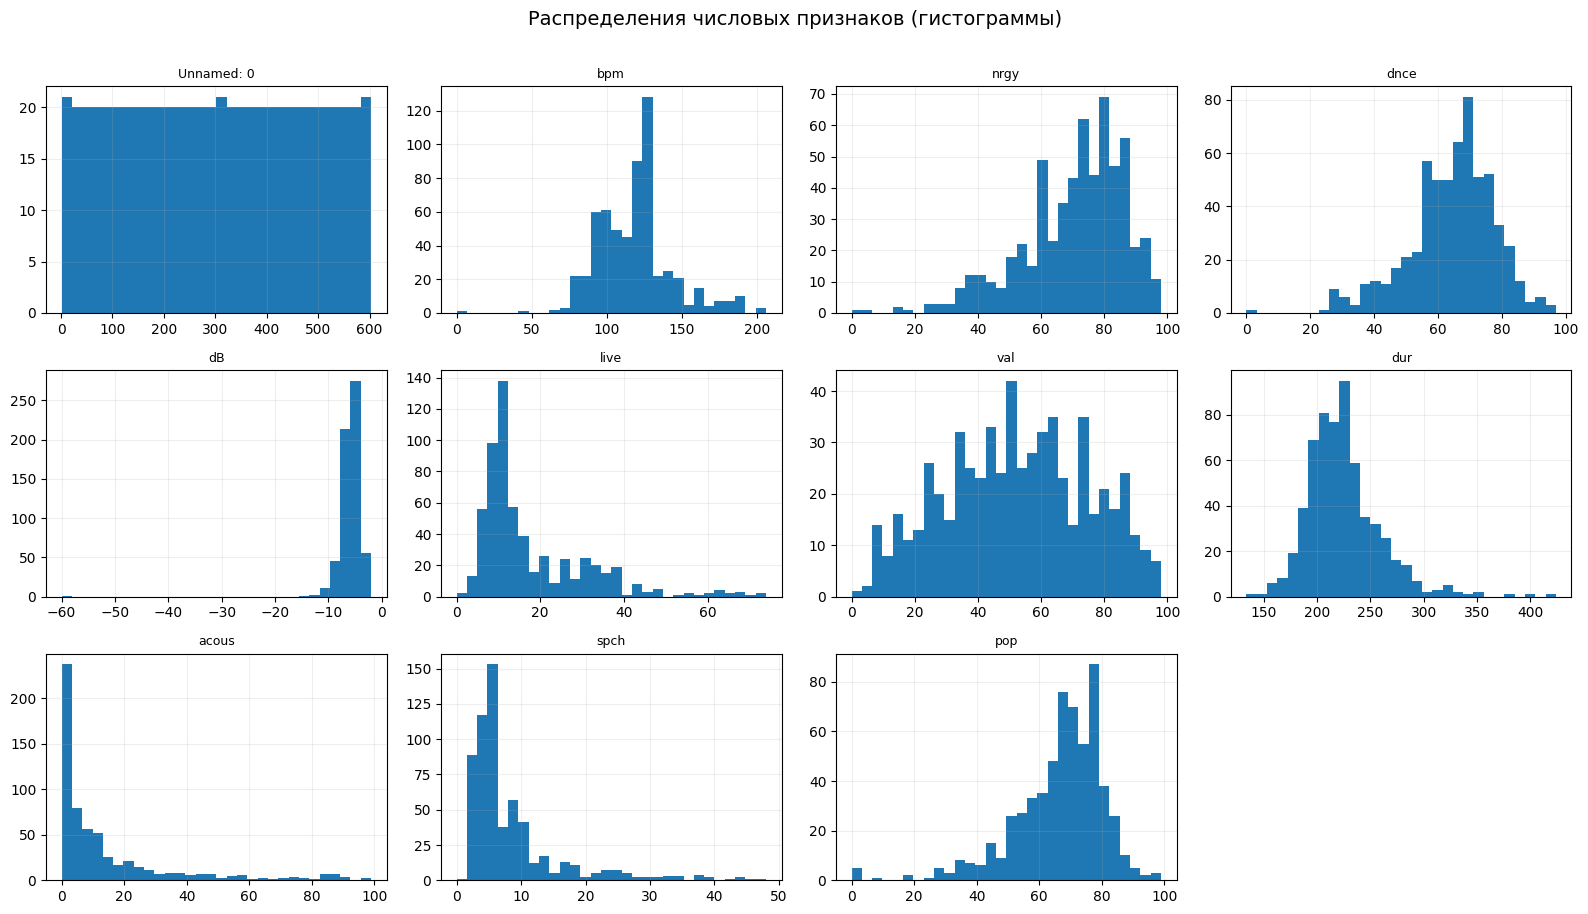

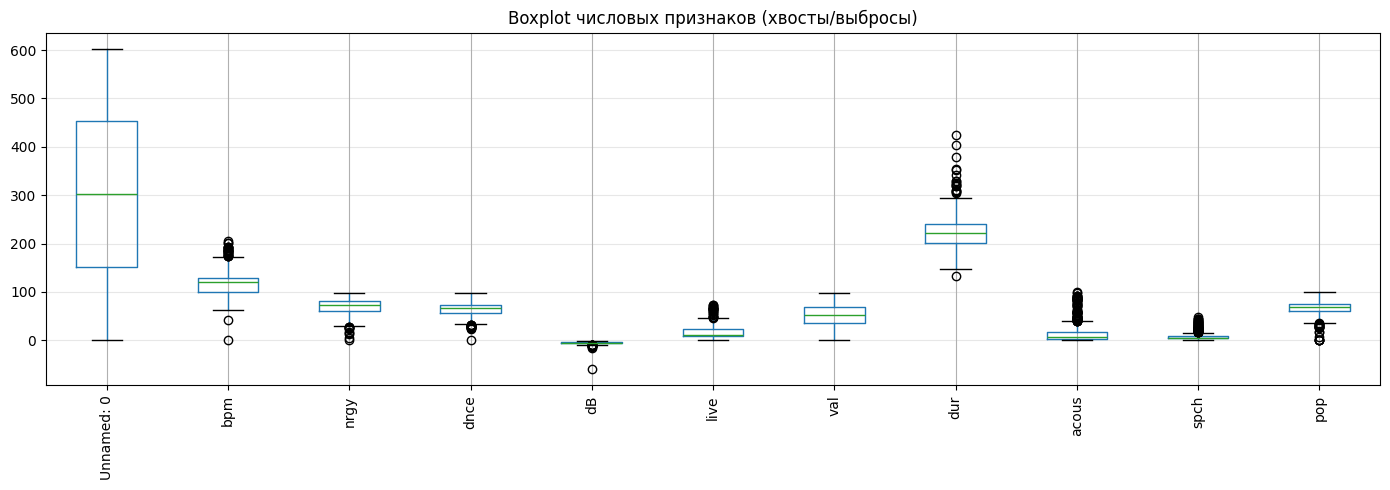

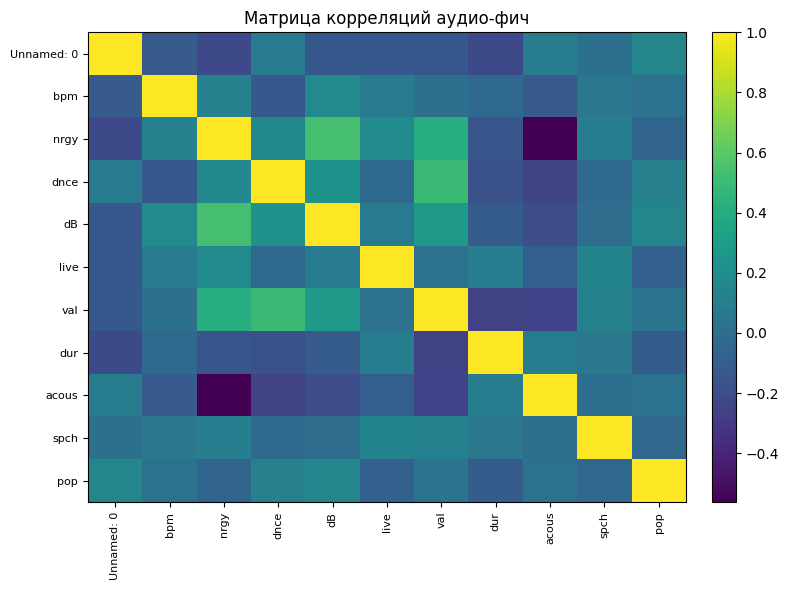

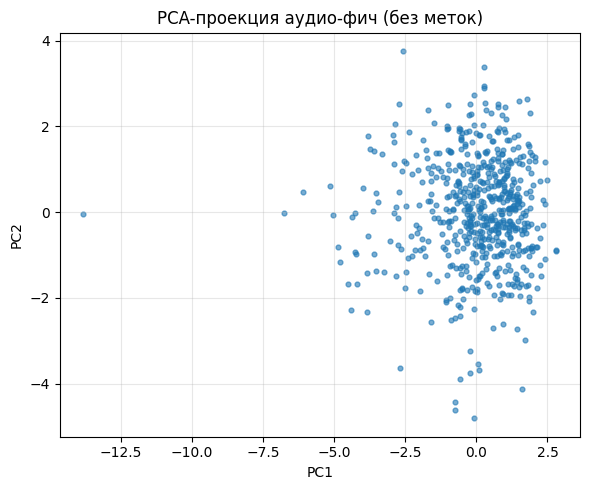

Доля объясненной дисперсии PCA(2): 0.375


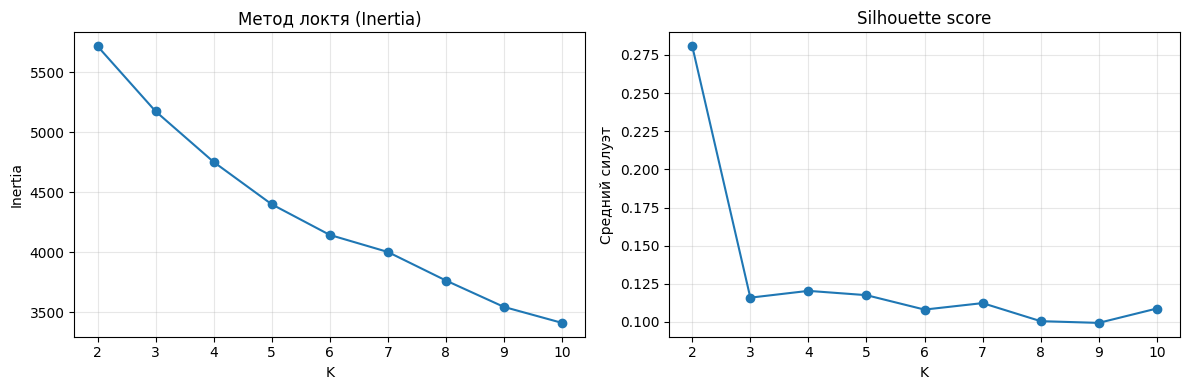


Таблица inertia и silhouette:
K=2: inertia=5715.44, silhouette=0.281
K=3: inertia=5172.90, silhouette=0.116
K=4: inertia=4750.91, silhouette=0.120
K=5: inertia=4398.40, silhouette=0.118
K=6: inertia=4143.23, silhouette=0.108
K=7: inertia=4001.13, silhouette=0.112
K=8: inertia=3763.41, silhouette=0.101
K=9: inertia=3543.34, silhouette=0.099
K=10: inertia=3410.38, silhouette=0.109

Лучший K по silhouette: 2 (silhouette=0.281)


In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ---------------------------
# 1) Загрузка и базовая инфа
# ---------------------------
df = pd.read_csv("top10s.csv", encoding="cp1252")

print("Размерность (rows, cols):", df.shape)
print("\nТипы признаков и пропуски:")
df.info()

print("\nПропуски по столбцам:")
print(df.isna().sum())

print("\nПервые строки:")
display(df.head())

# ---------------------------
# 2) Выбор числовых признаков
#    (оставляем только аудио-фичи)
# ---------------------------
# убираем явные не-фичи (имена/артисты/жанры/год)
drop_cols = [c for c in df.columns if c.lower() in
             ["title", "artist", "top genre", "genre", "year"]]

num_cols = df.drop(columns=drop_cols, errors="ignore").select_dtypes(include=[np.number]).columns.tolist()

print("\nЧисловые признаки для кластеризации:")
print(num_cols)

# ---------------------------
# 3) Дескриптивная статистика
# ---------------------------
desc = df[num_cols].describe().T
desc["skew"] = df[num_cols].skew()
desc["kurtosis"] = df[num_cols].kurtosis()
print("\nКраткая статистика:")
display(desc[["mean","std","min","25%","50%","75%","max","skew","kurtosis"]])

# ---------------------------
# 4) Распределения/хвосты:
#    гистограммы + boxplot
# ---------------------------
ncols = 4
nrows = int(np.ceil(len(num_cols) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3*nrows))
axes = axes.ravel()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=30)
    axes[i].set_title(col, fontsize=9)
    axes[i].grid(alpha=0.2)

for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Распределения числовых признаков (гистограммы)", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
df[num_cols].boxplot()
plt.title("Boxplot числовых признаков (хвосты/выбросы)")
plt.xticks(rotation=90)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# ---------------------------
# 5) Матрица корреляций
# ---------------------------
corr = df[num_cols].corr()

plt.figure(figsize=(8, 6))
im = plt.imshow(corr.values, aspect="auto")
plt.title("Матрица корреляций аудио-фич")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(num_cols)), num_cols, rotation=90, fontsize=8)
plt.yticks(range(len(num_cols)), num_cols, fontsize=8)
plt.tight_layout()
plt.show()

# ---------------------------
# 6) Масштабирование
# ---------------------------
# для Spotify-фич обычно хватает StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[num_cols])

# если увидишь сильные выбросы — можно заменить на RobustScaler:
# scaler = RobustScaler()
# X_scaled = scaler.fit_transform(df[num_cols])

# ---------------------------
# 7) Визуальная структура PCA 2D
# ---------------------------
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], s=12, alpha=0.6)
plt.title("PCA-проекция аудио-фич (без меток)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Доля объясненной дисперсии PCA(2): {pca.explained_variance_ratio_.sum():.3f}")

# ---------------------------
# 8) Подбор K: локоть + silhouette
# ---------------------------
Ks = range(2, 11)  # обычно для песен 2..10 достаточно
inertias = []
silhouettes = []

for k in Ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].plot(list(Ks), inertias, marker="o")
axes[0].set_title("Метод локтя (Inertia)")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inertia")
axes[0].grid(alpha=0.3)

axes[1].plot(list(Ks), silhouettes, marker="o")
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Средний силуэт")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nТаблица inertia и silhouette:")
for k, iner, sil in zip(Ks, inertias, silhouettes):
    print(f"K={k}: inertia={iner:.2f}, silhouette={sil:.3f}")

best_k = list(Ks)[int(np.argmax(silhouettes))]
best_sil = np.max(silhouettes)
print(f"\nЛучший K по silhouette: {best_k} (silhouette={best_sil:.3f})")


Размерность (rows, cols): (991, 22)

Типы признаков:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 991 entries, 0 to 990
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   index                       991 non-null    int64  
 1   brand                       991 non-null    object 
 2   Model                       991 non-null    object 
 3   Price                       991 non-null    int64  
 4   Rating                      991 non-null    int64  
 5   processor_brand             991 non-null    object 
 6   processor_tier              991 non-null    object 
 7   num_cores                   991 non-null    int64  
 8   num_threads                 991 non-null    int64  
 9   ram_memory                  991 non-null    int64  
 10  primary_storage_type        991 non-null    object 
 11  primary_storage_capacity    991 non-null    int64  
 12  secondary_storage_type      991 non-nul

,index,brand,Model,Price,Rating,processor_brand,processor_tier,num_cores,num_threads,ram_memory,...,secondary_storage_type,secondary_storage_capacity,gpu_brand,gpu_type,is_touch_screen,display_size,resolution_width,resolution_height,OS,year_of_warranty
0,1,tecno,Tecno Megabook T1 Laptop (11th Gen Core i3/ 8G...,23990,63,intel,core i3,2,4,8,...,No secondary storage,0,intel,integrated,False,15.6,1920,1080,windows,1
1,2,tecno,Tecno Megabook T1 Laptop (11th Gen Core i7/ 16...,35990,67,intel,core i7,4,8,16,...,No secondary storage,0,intel,integrated,False,15.6,1920,1080,windows,1
2,3,hp,HP Victus 15-fb0157AX Gaming Laptop (AMD Ryzen...,51100,73,amd,ryzen 5,6,12,8,...,No secondary storage,0,amd,dedicated,False,15.6,1920,1080,windows,1
3,4,acer,Acer Extensa EX214-53 Laptop (12th Gen Core i5...,39990,62,intel,core i5,12,16,8,...,No secondary storage,0,intel,integrated,False,14.0,1920,1080,windows,1
4,5,lenovo,Lenovo V15 82KDA01BIH Laptop (AMD Ryzen 3 5300...,28580,62,amd,ryzen 3,4,8,8,...,No secondary storage,0,amd,integrated,False,15.6,1920,1080,windows,1



Числовые признаки: ['Price', 'Rating', 'num_cores', 'num_threads', 'ram_memory', 'primary_storage_capacity', 'secondary_storage_capacity', 'is_touch_screen', 'display_size', 'resolution_width', 'resolution_height']

Категориальные признаки: ['brand', 'Model', 'processor_brand', 'processor_tier', 'primary_storage_type', 'secondary_storage_type', 'gpu_brand', 'gpu_type', 'OS', 'year_of_warranty']

Статистика числовых признаков:


,mean,std,min,25%,50%,75%,max,skew,kurtosis
Price,77266.504541,57384.910269,9800.0,43595.0,61900.0,89245.0,454490.0,2.779863,10.605194
Rating,63.931382,10.190575,24.0,58.0,64.0,71.0,89.0,-0.199286,0.406801
num_cores,8.128153,4.215499,2.0,6.0,8.0,10.0,24.0,1.125503,2.521836
num_threads,12.191726,5.585115,0.0,8.0,12.0,16.0,32.0,0.764674,1.977031
ram_memory,13.047427,5.591188,2.0,8.0,16.0,16.0,36.0,1.222642,2.900453
primary_storage_capacity,610.938446,266.927666,32.0,512.0,512.0,512.0,2048.0,1.735108,5.515427
secondary_storage_capacity,4.004036,33.553936,0.0,0.0,0.0,0.0,512.0,9.135307,92.599302
is_touch_screen,0.088799,0.284597,0.0,0.0,0.0,0.0,1.0,2.895546,6.397095
display_size,15.171241,0.938089,10.1,14.0,15.6,15.6,18.0,-0.942590,1.306193
resolution_width,2003.503532,361.965292,1080.0,1920.0,1920.0,1920.0,3840.0,1.515221,4.125688


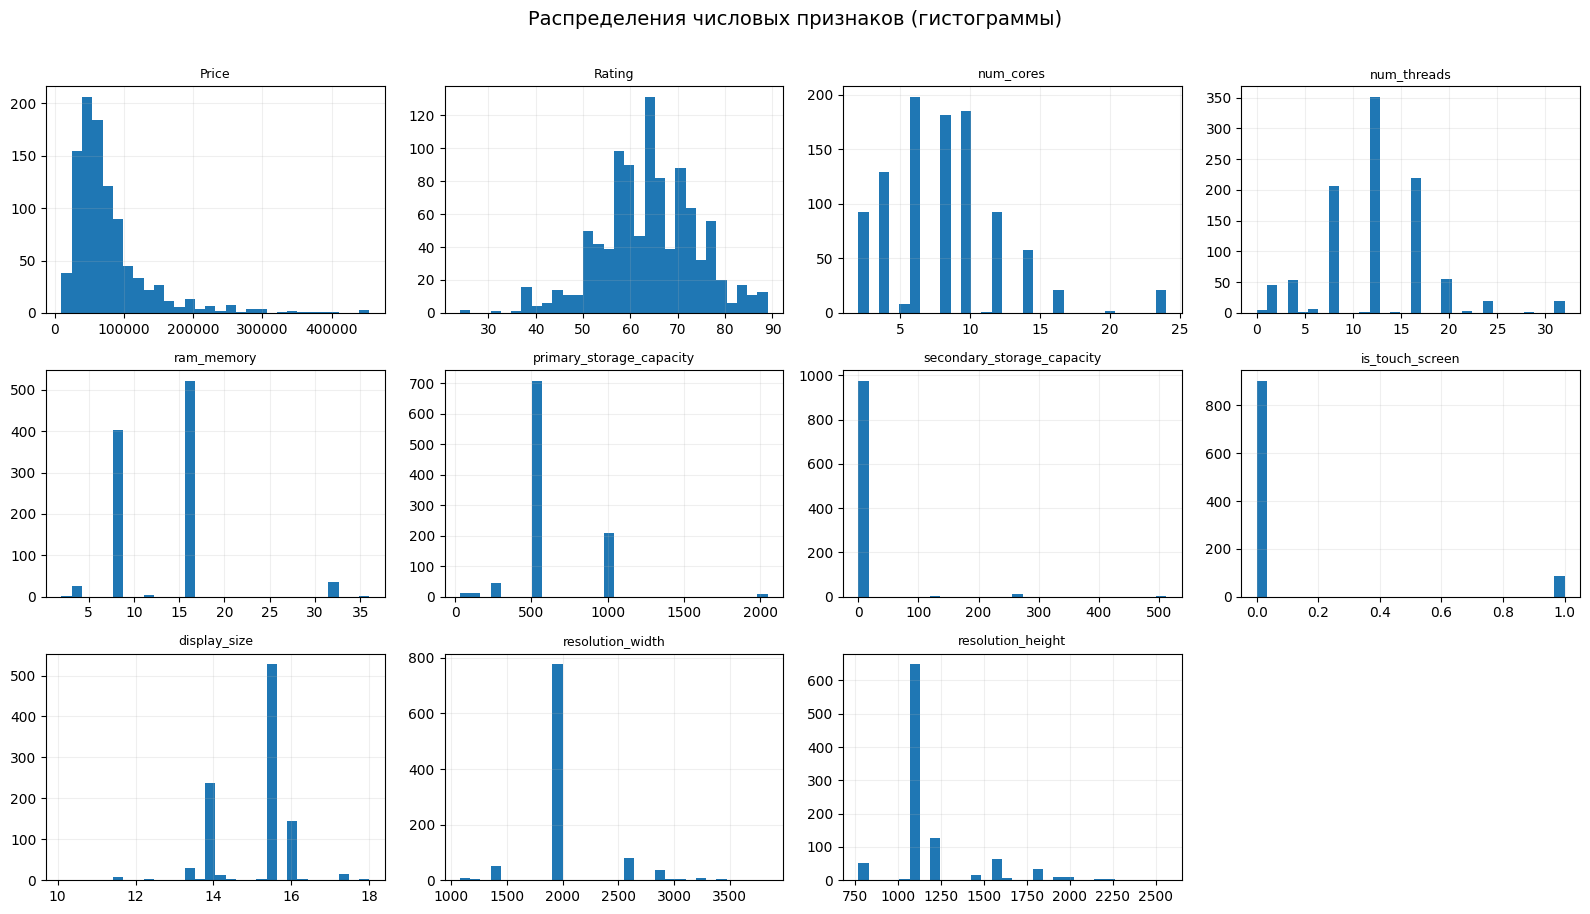

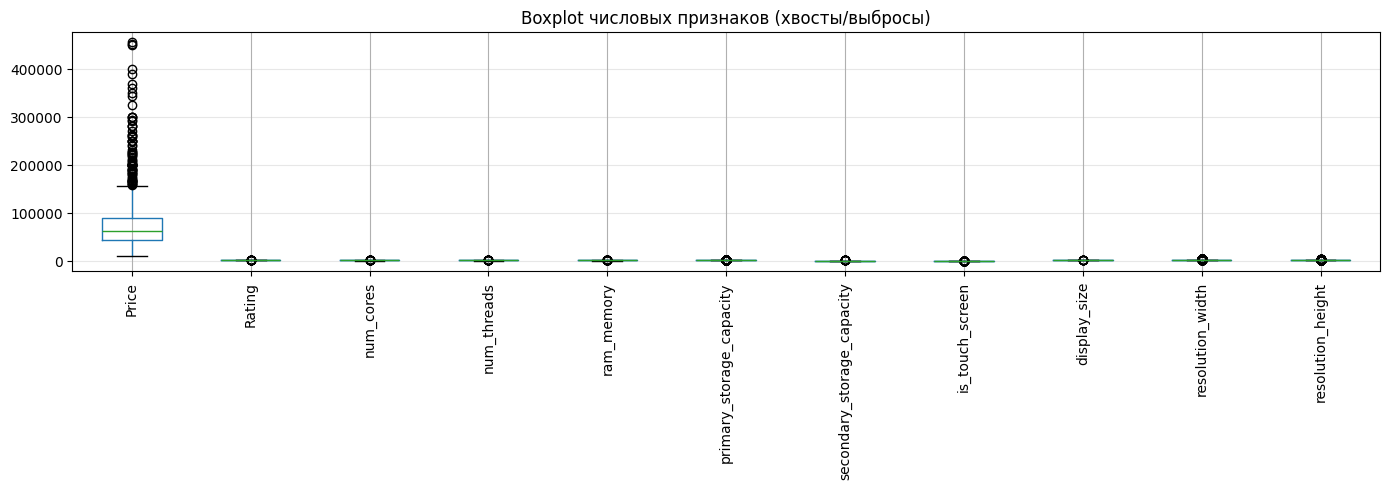

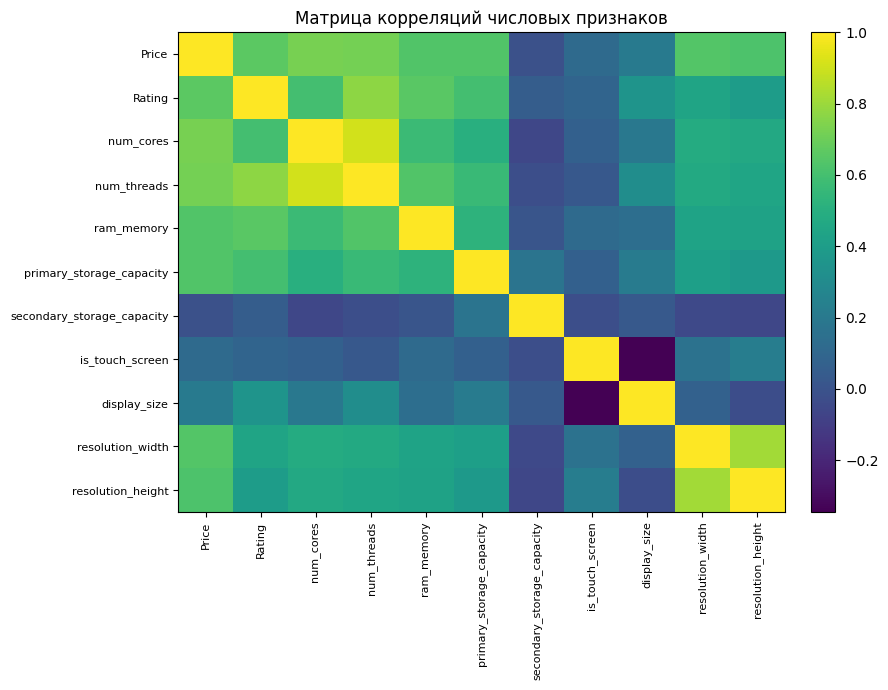

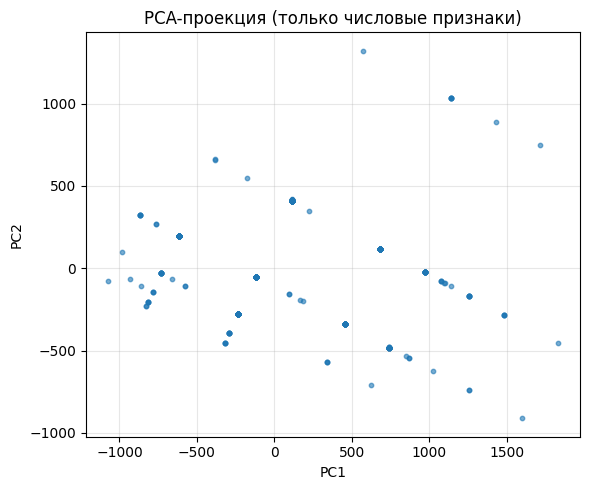

Доля объясненной дисперсии PCA(2): 0.995


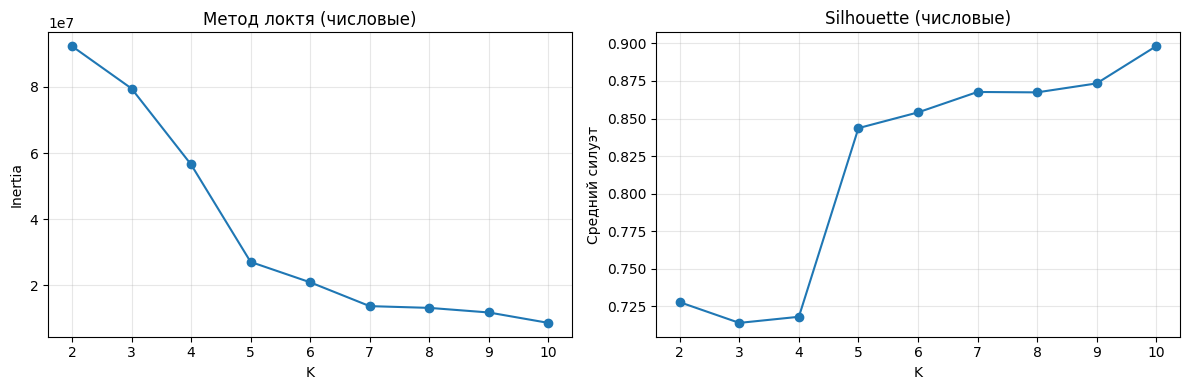


Таблица inertia и silhouette:
K=2: inertia=92327156.11, silhouette=0.728
K=3: inertia=79529272.98, silhouette=0.714
K=4: inertia=56564573.19, silhouette=0.718
K=5: inertia=27118226.56, silhouette=0.844
K=6: inertia=20958778.57, silhouette=0.854
K=7: inertia=13758760.00, silhouette=0.868
K=8: inertia=13230288.17, silhouette=0.867
K=9: inertia=11840663.52, silhouette=0.873
K=10: inertia=8694420.40, silhouette=0.898

Лучший K по silhouette (числовые): 10, sil=0.898

Подсказка:
Категориальные признаки НЕ включались в подбор K.
Их можно:
  A) не включать в кластеризацию, а использовать для интерпретации кластеров (бренды/CPU/GPU/OS).
  B) либо one-hot закодировать и потом сделать PCA перед кластеризацией (если хочешь учитывать всё).


In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ---------------------------
# 1) Загрузка и базовая инфа
# ---------------------------
df = pd.read_csv("laptops.csv")

print("Размерность (rows, cols):", df.shape)
print("\nТипы признаков:")
df.info()

print("\nПропуски по столбцам:")
print(df.isna().sum())

print("\nПервые строки:")
display(df.head())

# ---------------------------
# 2) Приведение некоторых столбцов
# ---------------------------
# index — служебный, не нужен как признак
if "index" in df.columns:
    df = df.drop(columns=["index"])

# is_touch_screen может быть строкой 'True/False' -> приведём к bool (если нужно)
if "is_touch_screen" in df.columns:
    df["is_touch_screen"] = df["is_touch_screen"].astype(str).str.lower().map({"true":1, "false":0}).fillna(df["is_touch_screen"])

# ---------------------------
# 3) Разделим признаки на числовые / категориальные
# ---------------------------
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in df.columns if c not in num_cols]

print("\nЧисловые признаки:", num_cols)
print("\nКатегориальные признаки:", cat_cols)

# ---------------------------
# 4) Дескриптивная статистика числовых
# ---------------------------
desc = df[num_cols].describe().T
desc["skew"] = df[num_cols].skew()
desc["kurtosis"] = df[num_cols].kurtosis()

print("\nСтатистика числовых признаков:")
display(desc[["mean","std","min","25%","50%","75%","max","skew","kurtosis"]])

# ---------------------------
# 5) Распределения/хвосты:
#    гистограммы + boxplot
# ---------------------------
ncols = 4
nrows = int(np.ceil(len(num_cols) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3*nrows))
axes = axes.ravel()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=30)
    axes[i].set_title(col, fontsize=9)
    axes[i].grid(alpha=0.2)

for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Распределения числовых признаков (гистограммы)", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
df[num_cols].boxplot()
plt.title("Boxplot числовых признаков (хвосты/выбросы)")
plt.xticks(rotation=90)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# ---------------------------
# 6) Корреляции по числовым
# ---------------------------
corr = df[num_cols].corr()

plt.figure(figsize=(9, 7))
im = plt.imshow(corr.values, aspect="auto")
plt.title("Матрица корреляций числовых признаков")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(num_cols)), num_cols, rotation=90, fontsize=8)
plt.yticks(range(len(num_cols)), num_cols, fontsize=8)
plt.tight_layout()
plt.show()

# ---------------------------
# 7) Масштабирование числовых
# ---------------------------
# Цена/память/ядра часто имеют хвосты, RobustScaler может быть чуть стабильнее
scaler = RobustScaler()
X_scaled = scaler.fit_transform(df[num_cols])

# ---------------------------
# 8) PCA 2D для визуальной структуры
# ---------------------------
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], s=10, alpha=0.6)
plt.title("PCA-проекция (только числовые признаки)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Доля объясненной дисперсии PCA(2): {pca.explained_variance_ratio_.sum():.3f}")

# ---------------------------
# 9) Подбор K (по числовым признакам)
# ---------------------------
Ks = range(2, 11)
inertias, silhouettes = [], []

for k in Ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].plot(list(Ks), inertias, marker="o")
axes[0].set_title("Метод локтя (числовые)")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inertia")
axes[0].grid(alpha=0.3)

axes[1].plot(list(Ks), silhouettes, marker="o")
axes[1].set_title("Silhouette (числовые)")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Средний силуэт")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nТаблица inertia и silhouette:")
for k, iner, sil in zip(Ks, inertias, silhouettes):
    print(f"K={k}: inertia={iner:.2f}, silhouette={sil:.3f}")

best_k = list(Ks)[int(np.argmax(silhouettes))]
print(f"\nЛучший K по silhouette (числовые): {best_k}, sil={np.max(silhouettes):.3f}")

# ---------------------------
# 10) Мини-вывод про категориальные
# ---------------------------
print("\nПодсказка:")
print("Категориальные признаки НЕ включались в подбор K.")
print("Их можно:")
print("  A) не включать в кластеризацию, а использовать для интерпретации кластеров (бренды/CPU/GPU/OS).")
print("  B) либо one-hot закодировать и потом сделать PCA перед кластеризацией (если хочешь учитывать всё).")


Размерность X: (13611, 16)
Размерность y: (13611, 1)

Типы признаков:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRatio      13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  Roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  f

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRatio,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,Roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166



Распределение классов (для проверки, НЕ использовать в кластеризации):


Class   
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64


Числовые признаки: ['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRatio', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 'Roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4']

Статистика признаков:


,mean,std,min,25%,50%,75%,max,skew,kurtosis
Area,53048.284549,29324.095717,20420.000000,36328.000000,44652.000000,61332.000000,254616.000000,2.952931,10.800814
Perimeter,855.283459,214.289696,524.736000,703.523500,794.941000,977.213000,1985.370000,1.626124,3.588123
MajorAxisLength,320.141867,85.694186,183.601165,253.303633,296.883367,376.495012,738.860154,1.357815,2.531902
MinorAxisLength,202.270714,44.970091,122.512653,175.848170,192.431733,217.031741,460.198497,2.238211,6.651067
AspectRatio,1.583242,0.246678,1.024868,1.432307,1.551124,1.707109,2.430306,0.582573,0.113814
Eccentricity,0.750895,0.092002,0.218951,0.715928,0.764441,0.810466,0.911423,-1.062824,1.387456
ConvexArea,53768.200206,29774.915817,20684.000000,36714.500000,45178.000000,62294.000000,263261.000000,2.941821,10.743640
EquivDiameter,253.064220,59.177120,161.243764,215.068003,238.438026,279.446467,569.374358,1.948958,5.192057
Extent,0.749733,0.049086,0.555315,0.718634,0.759859,0.786851,0.866195,-0.895348,0.643319
Solidity,0.987143,0.004660,0.919246,0.985670,0.988283,0.990013,0.994677,-2.550093,12.799621


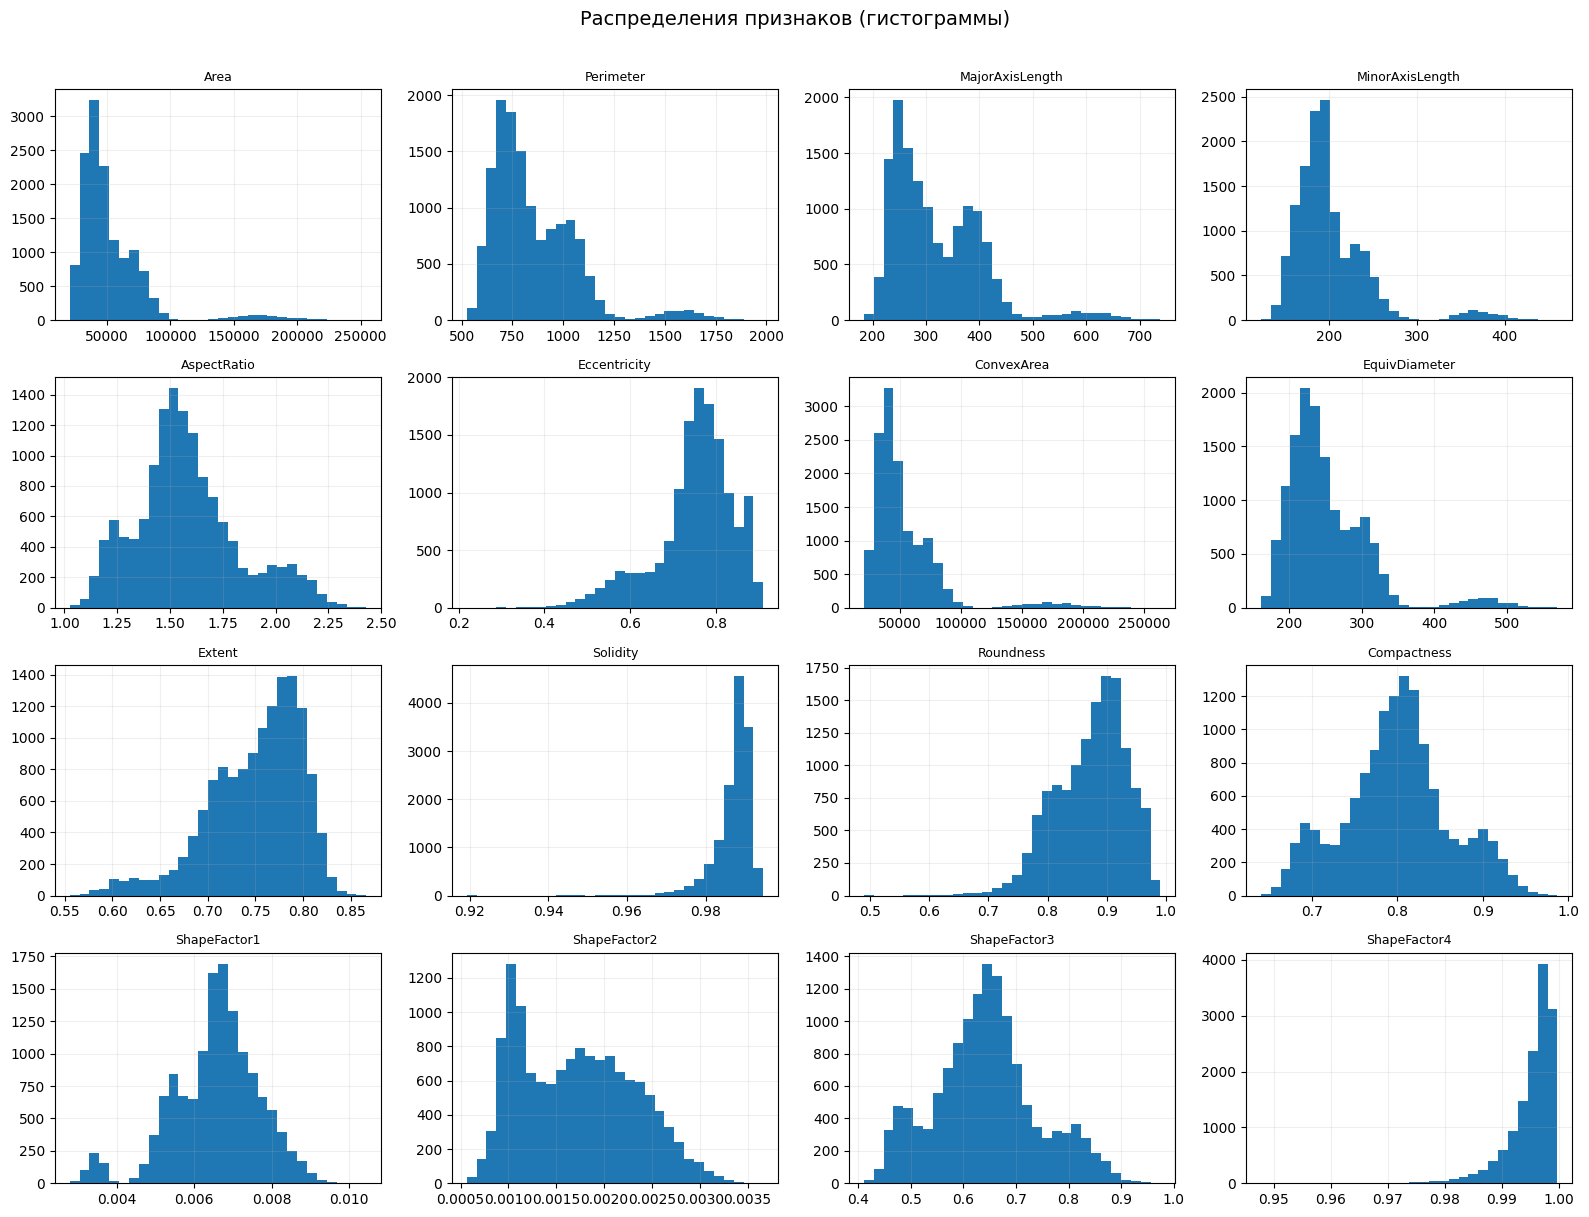

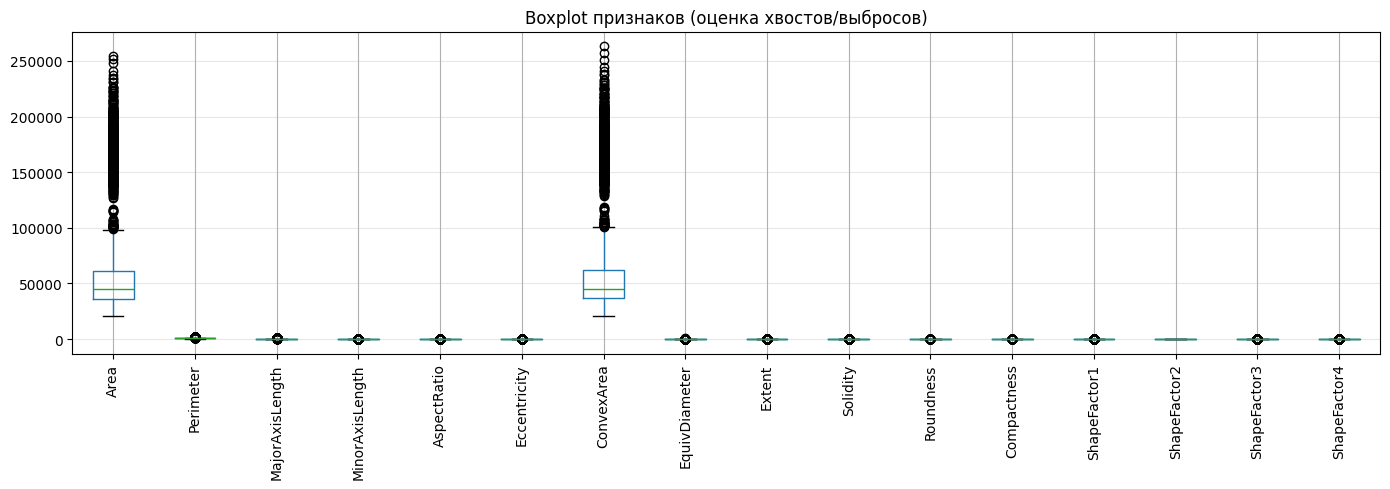

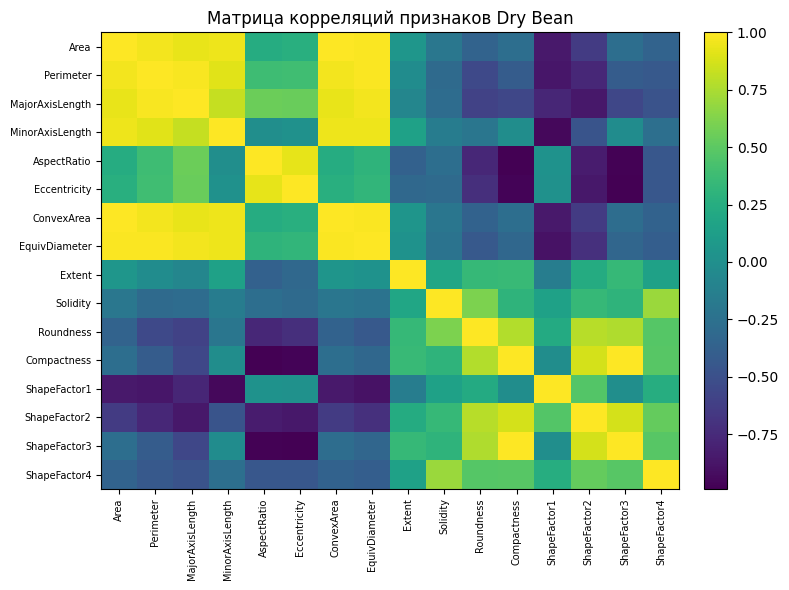

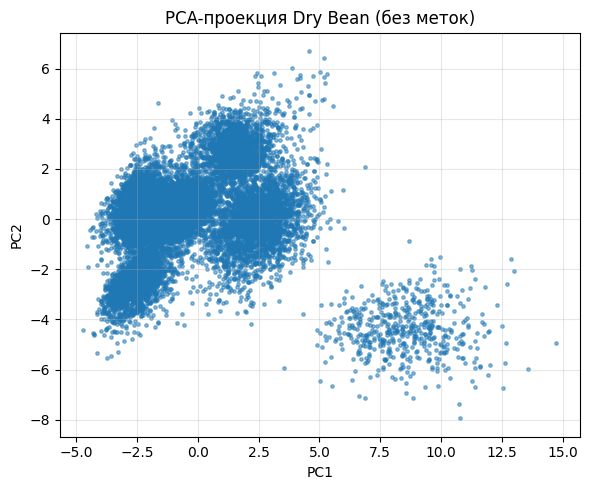

Доля объясненной дисперсии PCA(2): 0.817


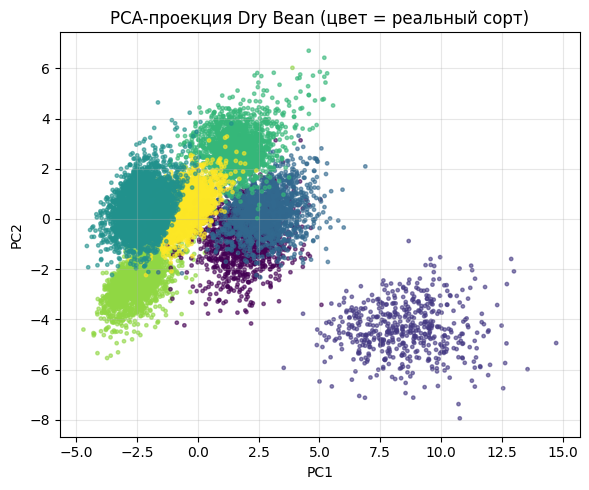

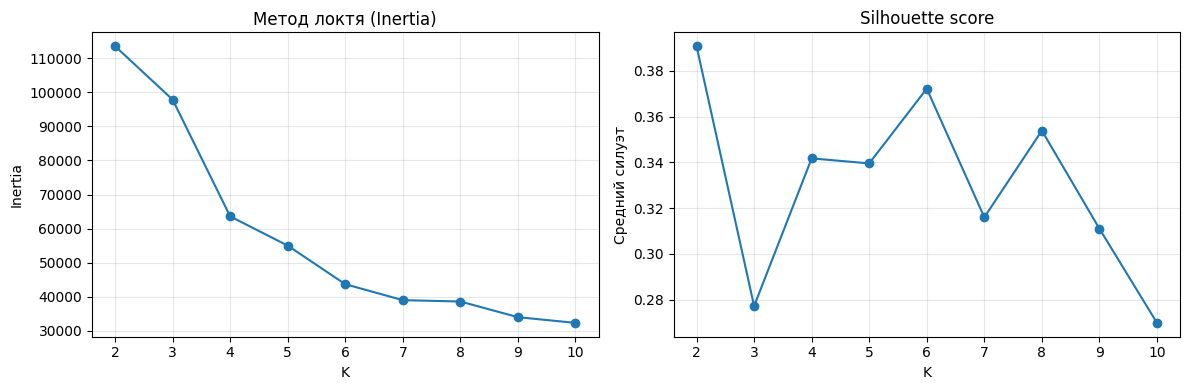


Таблица inertia и silhouette:
K=2: inertia=113495.47, silhouette=0.391
K=3: inertia=97826.98, silhouette=0.277
K=4: inertia=63599.71, silhouette=0.342
K=5: inertia=55021.57, silhouette=0.340
K=6: inertia=43705.82, silhouette=0.372
K=7: inertia=39032.01, silhouette=0.316
K=8: inertia=38636.22, silhouette=0.354
K=9: inertia=34043.82, silhouette=0.311
K=10: inertia=32367.44, silhouette=0.270

Лучший K по silhouette: 2 (sil=0.391)


In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# ---------------------------
# 1) Базовая инфа
# ---------------------------
print("Размерность X:", X.shape)
print("Размерность y:", y.shape)

print("\nТипы признаков:")
X.info()

print("\nПропуски по столбцам:")
print(X.isna().sum())

print("\nПервые строки X:")
display(X.head())

print("\nРаспределение классов (для проверки, НЕ использовать в кластеризации):")
display(y.value_counts())

# ---------------------------
# 2) Числовые признаки
# (в dry bean все фичи числовые)
# ---------------------------
num_cols = X.columns.tolist()
print("\nЧисловые признаки:", num_cols)

# ---------------------------
# 3) Дескриптивная статистика
# ---------------------------
desc = X.describe().T
desc["skew"] = X.skew()
desc["kurtosis"] = X.kurtosis()

print("\nСтатистика признаков:")
display(desc[["mean","std","min","25%","50%","75%","max","skew","kurtosis"]])

# ---------------------------
# 4) Распределения/хвосты
# ---------------------------
ncols = 4
nrows = int(np.ceil(len(num_cols) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3*nrows))
axes = axes.ravel()

for i, col in enumerate(num_cols):
    axes[i].hist(X[col].dropna(), bins=30)
    axes[i].set_title(col, fontsize=9)
    axes[i].grid(alpha=0.2)

for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Распределения признаков (гистограммы)", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
X.boxplot()
plt.title("Boxplot признаков (оценка хвостов/выбросов)")
plt.xticks(rotation=90)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# ---------------------------
# 5) Матрица корреляций
# ---------------------------
corr = X.corr()

plt.figure(figsize=(8, 6))
im = plt.imshow(corr.values, aspect="auto")
plt.title("Матрица корреляций признаков Dry Bean")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(num_cols)), num_cols, rotation=90, fontsize=7)
plt.yticks(range(len(num_cols)), num_cols, fontsize=7)
plt.tight_layout()
plt.show()

# ---------------------------
# 6) Масштабирование
# ---------------------------
# у бобов могут быть хвосты => RobustScaler обычно уместен
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# ---------------------------
# 7) PCA 2D для визуальной оценки структуры
# ---------------------------
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], s=6, alpha=0.5)
plt.title("PCA-проекция Dry Bean (без меток)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Доля объясненной дисперсии PCA(2): {pca.explained_variance_ratio_.sum():.3f}")

# (опционально) раскраска по реальным типам бобов — только для проверки
y_codes = y.iloc[:,0].astype("category").cat.codes
plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_codes, s=6, alpha=0.6)
plt.title("PCA-проекция Dry Bean (цвет = реальный сорт)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ---------------------------
# 8) Подбор K (локоть + silhouette)
# ---------------------------
Ks = range(2, 11)
inertias, silhouettes = [], []

for k in Ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].plot(list(Ks), inertias, marker="o")
axes[0].set_title("Метод локтя (Inertia)")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inertia")
axes[0].grid(alpha=0.3)

axes[1].plot(list(Ks), silhouettes, marker="o")
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Средний силуэт")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nТаблица inertia и silhouette:")
for k, iner, sil in zip(Ks, inertias, silhouettes):
    print(f"K={k}: inertia={iner:.2f}, silhouette={sil:.3f}")

best_k = list(Ks)[int(np.argmax(silhouettes))]
print(f"\nЛучший K по silhouette: {best_k} (sil={np.max(silhouettes):.3f})")
